# 多维数组的运算

- 📅 2026-07-11
- 🏷️ 神经网络基础, NumPy, 矩阵运算
- 📖 参考：《深度学习入门》第3章 3.3 节

## 1. 为什么需要多维数组

神经网络的计算，本质就是把一堆数字按权重加权求和：

$$a_j = b_j + w_{1j}x_1 + w_{2j}x_2 + \dots + w_{nj}x_n$$

如果有 784 个输入、50 个隐藏神经元，一个一个算要写到手断。

**矩阵乘法一次搞定**：

$$\mathbf{A} = \mathbf{X} \cdot \mathbf{W} + \mathbf{B}$$

```
     X(1×784)  ×  W(784×50)  =  A(1×50)
     1张图        权重矩阵       50个神经元的加权和
```

In [14]:
import numpy as np

## 2. 一维数组 → 向量

最简单的多维数组：一维数组，就是向量。

In [15]:
# 一维数组
x = np.array([1, 2, 3])
print('x =', x)
print('维度数:', x.ndim)     # 1 维
print('形状:', x.shape)      # (3,) — 3 个元素
print('元素类型:', x.dtype)

x = [1 2 3]
维度数: 1
形状: (3,)
元素类型: int64


## 3. 二维数组 → 矩阵

二维数组就是矩阵，神经网络里权重就是矩阵。

In [16]:
# 二维数组（矩阵）
W = np.array([[1, 2, 3],
              [4, 5, 6]])

print('W =')
print(W)
print('维度数:', W.ndim)   # 2
print('形状:', W.shape)    # (2, 3) — 2行3列

W =
[[1 2 3]
 [4 5 6]]
维度数: 2
形状: (2, 3)


## 4. 矩阵乘法（内积）

用 `np.dot()` 做矩阵乘法。规则：**左矩阵的列数必须等于右矩阵的行数**。

```
(m × n) · (n × p) → (m × p)
    ↑       ↑
    这两个 n 必须相等
```

In [17]:
# 例 1：向量 × 矩阵
# (1×2) · (2×3) → (1×3)

X = np.array([1, 2])                    # shape (2,)
W = np.array([[1, 3, 5],
              [2, 4, 6]])               # shape (2, 3)

Y = np.dot(X, W)                        # shape (3,)
print('X(2,) · W(2×3) =', Y)
print()
print('手算验证: [1×1+2×2, 1×3+2×4, 1×5+2×6]')
print('        = [', 1*1+2*2, ',', 1*3+2*4, ',', 1*5+2*6, ']')

X(2,) · W(2×3) = [ 5 11 17]

手算验证: [1×1+2×2, 1×3+2×4, 1×5+2×6]
        = [ 5 , 11 , 17 ]


In [18]:
# 例 2：矩阵 × 矩阵
# (2×2) · (2×3) → (2×3)

X = np.array([[1, 2],       # 2 个样本
              [3, 4]])      # shape (2, 2)

W = np.array([[1, 3, 5],    # 权重
              [2, 4, 6]])   # shape (2, 3)

Y = np.dot(X, W)             # shape (2, 3)
print('X(2×2) · W(2×3) =')
print(Y)
print()
print('第 1 行 = 样本 1 对 3 个神经元的输入')
print('第 2 行 = 样本 2 对 3 个神经元的输入')

X(2×2) · W(2×3) =
[[ 5 11 17]
 [11 25 39]]

第 1 行 = 样本 1 对 3 个神经元的输入
第 2 行 = 样本 2 对 3 个神经元的输入


## 5. 神经网络中的内积

一个完整的层 = `np.dot(输入, 权重) + 偏置` → `激活函数`

```
         ┌──────────┐
    x₁ → │ w11 w12  │ → a₁ = x₁·w11 + x₂·w21 + b₁
    x₂ → │ w21 w22  │ → a₂ = x₁·w12 + x₂·w22 + b₂
         └──────────┘
    输入    权重 W      加权和 a = X·W + B
```

In [19]:
# 模拟：输入层(3) → 隐藏层(2)
X = np.array([0.5, -0.3, 1.0])             # 1 个样本，3 个特征
W = np.array([[0.1, 0.5],                   # 权重 (3×2)
              [-0.3, 0.2],
              [0.4, -0.1]])
B = np.array([0.2, -0.1])                   # 偏置 (2,)

# 一层的前向计算
A = np.dot(X, W) + B                        # 加权和 (2,)
print('X·W + B =', A)
print()
print(f'神经元 1: {0.5}×{0.1} + { -0.3}×{-0.3} + {1.0}×{0.4} + {0.2} = {0.5*0.1 + (-0.3)*(-0.3) + 1.0*0.4 + 0.2}')
print(f'神经元 2: {0.5}×{0.5} + { -0.3}×{0.2} + {1.0}×{-0.1} + {-0.1} = {0.5*0.5 + (-0.3)*0.2 + 1.0*(-0.1) + (-0.1)}')

X·W + B = [ 0.74 -0.01]

神经元 1: 0.5×0.1 + -0.3×-0.3 + 1.0×0.4 + 0.2 = 0.74
神经元 2: 0.5×0.5 + -0.3×0.2 + 1.0×-0.1 + -0.1 = -0.010000000000000009


## 6. 批处理 — 真正的威力

一次算**一个样本**和一次算**一批样本**，写法几乎一样：

```
单样本: (784,)    → network → (10,)    ← 1 张图
批处理: (100,784) → network → (100,10) ← 100 张图一次搞定
```

区别只是输入多了一个维度，`np.dot` 自动处理。

In [20]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 中文字体
fm._load_fontmanager(try_read_cache=False)
fm.fontManager.addfont('/System/Library/Fonts/PingFang.ttc')
prop = fm.FontProperties(fname='/System/Library/Fonts/PingFang.ttc')
plt.rcParams['font.sans-serif'] = [prop.get_name(), 'Heiti SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [21]:
# 批处理示例
X_batch = np.array([[0.5, -0.3, 1.0],    # 样本 1
                    [0.2, 0.8, -0.5],    # 样本 2
                    [1.0, 0.0, 0.3]])    # 样本 3
# shape (3, 3) — 3 个样本，每个 3 个特征

# 完全相同的计算！
A_batch = np.dot(X_batch, W) + B           # shape (3, 2)
print('批处理结果 (3×2):')
print(A_batch)
print()
print('第 1 行 = 样本 1 对 2 个神经元的输出')
print('第 2 行 = 样本 2 对 2 个神经元的输出')
print('第 3 行 = 样本 3 对 2 个神经元的输出')

批处理结果 (3×2):
[[ 0.74 -0.01]
 [-0.22  0.21]
 [ 0.42  0.37]]

第 1 行 = 样本 1 对 2 个神经元的输出
第 2 行 = 样本 2 对 2 个神经元的输出
第 3 行 = 样本 3 对 2 个神经元的输出


逐个样本（for 循环）: 0.3699s
批处理（矩阵乘法）  : 0.0290s
加速 13 倍
结果一致: True


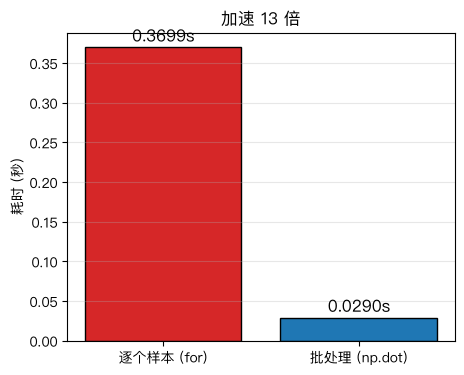

In [22]:
# 性能对比：单样本 vs 批处理
import time

N = 10000
X = np.random.randn(N, 784)
W = np.random.randn(784, 100)

# 逐个样本（慢）
start = time.time()
result_loop = np.zeros((N, 100))
for i in range(N):
    result_loop[i] = np.dot(X[i], W)
loop_time = time.time() - start

# 批处理（快）
start = time.time()
result_batch = np.dot(X, W)
batch_time = time.time() - start

print(f'逐个样本（for 循环）: {loop_time:.4f}s')
print(f'批处理（矩阵乘法）  : {batch_time:.4f}s')
print(f'加速 {loop_time / batch_time:.0f} 倍')
print(f'结果一致: {np.allclose(result_loop, result_batch)}')

# 可视化
plt.figure(figsize=(5, 4))
times = [loop_time, batch_time]
plt.bar(['逐个样本 (for)', '批处理 (np.dot)'], times, color=['C3', 'C0'], edgecolor='k')
plt.ylabel('耗时 (秒)')
plt.title(f'加速 {loop_time / batch_time:.0f} 倍')
for i, t in enumerate(times):
    plt.text(i, t + max(times)*0.02, f'{t:.4f}s', ha='center', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## 7. 形状一致性的坑

神经网络里最常见的 bug：形状对不上。打印 `shape` 是最快的 debug 方式。

In [23]:
# 常见错误示例
X = np.random.randn(100, 784)    # 100 张图
W1 = np.random.randn(784, 50)    # 输入 → 隐藏
W2 = np.random.randn(50, 100)    # 隐藏 → 隐藏
W3 = np.random.randn(100, 10)    # 隐藏 → 输出（10 分类）

# 逐层追踪形状变化
print('输入 (batch, features):')
a1 = np.dot(X, W1)
print(f'  X(100,784) · W1(784,50) → (100,50)  ✓')

a2 = np.dot(a1, W2)
print(f'  a1(100,50) · W2(50,100) → (100,100)  ✓')

a3 = np.dot(a2, W3)
print(f'  a2(100,100) · W3(100,10) → (100,10)  ✓')
print()
print('每行是一个样本对 10 个类别的得分')

输入 (batch, features):
  X(100,784) · W1(784,50) → (100,50)  ✓
  a1(100,50) · W2(50,100) → (100,100)  ✓
  a2(100,100) · W3(100,10) → (100,10)  ✓

每行是一个样本对 10 个类别的得分


## 8. 核心公式速查

| 操作 | 公式 | NumPy |
|------|------|-------|
| 加权和 | $\mathbf{A} = \mathbf{X}\mathbf{W} + \mathbf{b}$ | `np.dot(X, W) + b` |
| Sigmoid | $\sigma(x) = 1/(1+e^{-x})$ | `1/(1+np.exp(-x))` |
| ReLU | $\max(0, x)$ | `np.maximum(0, x)` |
| Softmax | $e^{a_k}/\sum e^{a_i}$ | `np.exp(a-c)/np.sum(np.exp(a-c))` |
| 形状检查 | — | `print(arr.shape)` |

> **记住一条**：神经网络里所有核心运算就是 `np.dot`。前向是 `np.dot`，反向也是 `np.dot`（只不过转置一下）。
>
> 把矩阵乘法搞懂，神经网络就懂了一半。

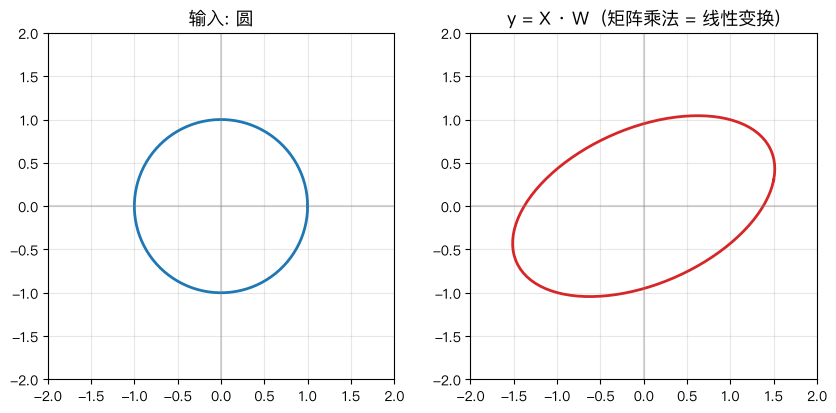

In [24]:
# 可视化：矩阵乘法 = 空间变换
# 一个圆经过矩阵变换后变成椭圆，直观感受"线性变换"

theta = np.linspace(0, 2*np.pi, 100)
circle = np.column_stack([np.cos(theta), np.sin(theta)])  # shape (100, 2)

# 一个 2×2 矩阵 = 缩放+旋转
W_transform = np.array([[1.5, 0.3],
                         [0.2, 1.0]])

transformed = np.dot(circle, W_transform)  # (100, 2) · (2, 2) → (100, 2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].plot(circle[:, 0], circle[:, 1], 'C0', linewidth=2)
axes[0].axhline(0, color='gray', alpha=0.3)
axes[0].axvline(0, color='gray', alpha=0.3)
axes[0].set_xlim(-2, 2); axes[0].set_ylim(-2, 2)
axes[0].set_aspect('equal')
axes[0].set_title('输入: 圆', fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].plot(transformed[:, 0], transformed[:, 1], 'C3', linewidth=2)
axes[1].axhline(0, color='gray', alpha=0.3)
axes[1].axvline(0, color='gray', alpha=0.3)
axes[1].set_xlim(-2, 2); axes[1].set_ylim(-2, 2)
axes[1].set_aspect('equal')
axes[1].set_title('y = X · W  (矩阵乘法 = 线性变换)', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.show()